In [1]:
import jax
import flax
import optax
from jax import lax, random, value_and_grad, numpy as jnp
from jax import random, grad, vmap, hessian, jacfwd, jit
from jax import config
from jax.tree_util import Partial
from flax import linen as nn
import jax_dataloader as jd

import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors

import torch
from torch.utils.data import Dataset

import os
from tqdm.auto import tqdm

config.update("jax_enable_x64", True)
os.environ['XLA_PYTHON_CLIENT_ALLOCATOR'] = 'cuda_async'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'true' # default is true, 90% of GPU VRAM preallocated

In [2]:
DATA_DIR = Path.cwd().parent.parent / "data" / "poisson-gauss" / "snapshots"
FILE_PATH = DATA_DIR / "Poisson-Gauss.nc" 
FILE_MORE_PARAMS_PATH = DATA_DIR / "poisson_gauss_parameters.csv"

In [3]:
epochs = 10
M = 256
chunk_size = 256 # For total_features
hidden_layers = [128, 128, 128, 128] 
total_features = sum(hidden_layers) # 128*4 = 512

kaczmarz_sweeps = 20
kaczmarz_alpha = 0.3 # Relaxation parameter
kaczmarz_tik_reg = 2e-6

print(total_features)

# total_features to be perfectly divisible by chunk_size for our jax.lax.scan loops to work
if total_features % chunk_size != 0:
    raise ValueError(
        f"total_features ({total_features}) must be divisible by "
        f"chunk_size ({chunk_size})"
    )

512


Dataset summary:
<xarray.Dataset> Size: 3GB
Dimensions:   (sample: 20000, x: 128, y: 128)
Dimensions without coordinates: sample, x, y
Data variables:
    solution  (sample, x, y) float32 1GB ...
    source    (sample, x, y) float32 1GB ...

Extracted Source Shape: (128, 128)
Extracted Solution Shape: (128, 128)


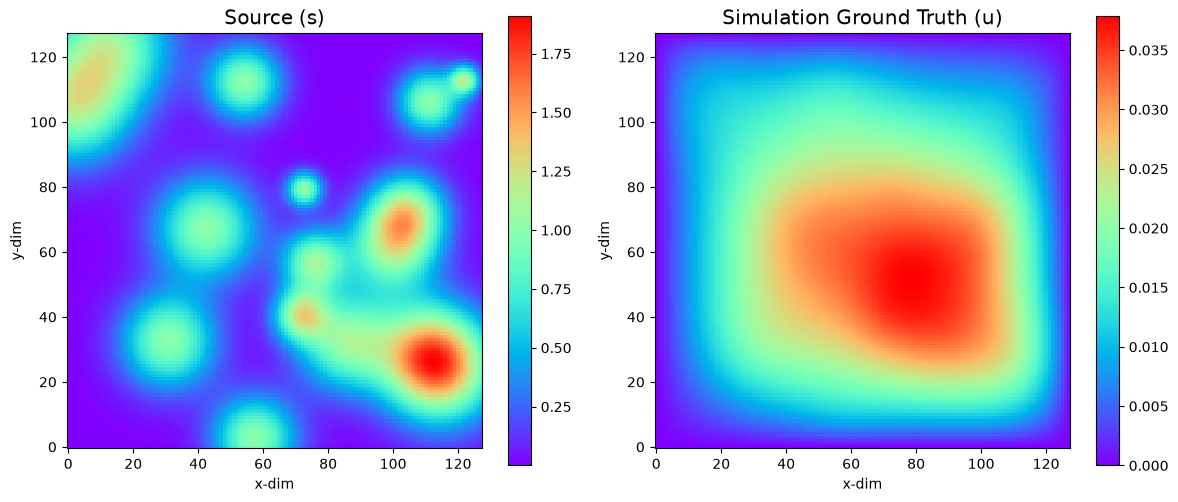

In [4]:
import xarray as xr

ds = xr.open_dataset(FILE_PATH)
print(f"Dataset summary:\n{ds}\n")

sample_idx = 19808

source_sample = ds['source'][sample_idx].values
solution_sample = ds['solution'][sample_idx].values

print(f"Extracted Source Shape: {source_sample.shape}")
print(f"Extracted Solution Shape: {solution_sample.shape}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im1 = axes[0].imshow(source_sample.T, origin='lower', cmap='rainbow')
fig.colorbar(im1, ax=axes[0])
axes[0].set_title('Source (s)', fontsize='x-large')
axes[0].set_xlabel('x-dim')
axes[0].set_ylabel('y-dim')

im2 = axes[1].imshow(solution_sample.T, origin='lower', cmap='rainbow')
fig.colorbar(im2, ax=axes[1])
axes[1].set_title('Simulation Ground Truth (u)', fontsize='x-large')
axes[1].set_xlabel('x-dim')
axes[1].set_ylabel('y-dim')
plt.tight_layout()
plt.show()

ds.close()

In [5]:
class PoissonGaussDataset(Dataset):
    def __init__(self, source_data, solution_data):
        self.s = source_data.reshape(source_data.shape[0], -1, 1)
        self.u = solution_data.reshape(solution_data.shape[0], -1, 1)

    def __len__(self):
        return len(self.u)

    def __getitem__(self, idx):
        return self.s[idx], self.u[idx]

ds = xr.open_dataset(FILE_PATH)
all_source = ds['source'].values
all_solution = ds['solution'].values
ds.close()

n_train, n_val, n_test = 19640, 120, 240

train_dataset = PoissonGaussDataset(all_source[:n_train], all_solution[:n_train])
val_dataset = PoissonGaussDataset(all_source[n_train:n_train+n_val], all_solution[n_train:n_train+n_val])
test_dataset = PoissonGaussDataset(all_source[-n_test:], all_solution[-n_test:])

batch_size_samples = 32
train_dataloader = jd.DataLoader(train_dataset, backend='pytorch', batch_size=batch_size_samples, shuffle=True, drop_last=True, num_workers=0)
val_dataloader = jd.DataLoader(val_dataset, backend='pytorch', batch_size=batch_size_samples, shuffle=False, num_workers=0)
test_dataloader = jd.DataLoader(test_dataset, backend='pytorch', batch_size=batch_size_samples, shuffle=False, num_workers=0)

print("DataLoaders ready!")

DataLoaders ready!


In [6]:
nx, ny = source_sample.shape # 128, 128

# normalize
x_coords = np.linspace(0.0, 1.0, nx, dtype=np.float64)
y_coords = np.linspace(0.0, 1.0, ny, dtype=np.float64)

X, Y = np.meshgrid(x_coords, y_coords, indexing='ij')

x = jnp.array(X.reshape(-1, 1))
y = jnp.array(Y.reshape(-1, 1))

s = jnp.array(source_sample.reshape(-1, 1), dtype=jnp.float64)
u_sim = jnp.array(solution_sample.reshape(-1, 1), dtype=jnp.float64)

# Dirichlet Boundary Condition
x_l, x_u = 0.0, 1.0
y_l, y_u = 0.0, 1.0

bc_left = (x == x_l).flatten() # Array([ True,  True,  True, ..., False, False, False], dtype=bool)
bc_right = (x == x_u).flatten()
bc_bottom = (y == y_l).flatten()
bc_top = (y == y_u).flatten()

bc_all = bc_left | bc_right | bc_bottom | bc_top # an array of True if on boundary, False if not on boundary.

# Extract only boundary coordinates
x_bc = x[bc_all]
y_bc = y[bc_all]

u_bc = jnp.zeros_like(x_bc) # Dirichlet u=0


In [7]:
# Setup the RFF Matrix
sigma = 0.5 

rff_key = jax.random.PRNGKey(99)
B_matrix = jax.random.normal(rff_key, (2, M)) * sigma # M is num_frequencies

class FeatureExtractor(nn.Module):
    hidden_layers: list
    B_matrix: jnp.ndarray 
    
    @nn.compact
    def __call__(self, x_in, y_in):    
        self.param('raw_lambda', nn.initializers.constant(-3.0), (1,)) # gives 1e-5 initialization
        
        v = jnp.concatenate([x_in, y_in])

        proj = 2.0 * jnp.pi * jnp.dot(v, self.B_matrix)
        h_rff = jnp.concatenate([jnp.sin(proj), jnp.cos(proj)])
        all_features = []

        h = h_rff
        for size in self.hidden_layers:
            h = nn.Dense(size, kernel_init=nn.initializers.he_normal())(h)
            h = nn.tanh(h) 
            all_features.append(h)
            
        # Combine RFF and MLP layers
        # Shape becomes: 128 + 128 + 128 + 128 = 512 nodes
        combined_h = jnp.concatenate(all_features)
            
        return combined_h
    
model = FeatureExtractor(
    hidden_layers=hidden_layers, 
    B_matrix=B_matrix 
)

# Dummy initialization to get the shapes right
key = jax.random.PRNGKey(0)
dummy_x = jnp.array([0.0])
dummy_y = jnp.array([0.0])
params = model.init(key, dummy_x, dummy_y)

In [8]:
def get_f_chunk(params, x_val, y_val, start_idx, chunk_size):
    f = model.apply(params, x_val, y_val)
    return jax.lax.dynamic_slice(f, (start_idx,), (chunk_size,))

def get_f_dir_chunk(params, x_val, y_val, start_idx, chunk_size):
    def f_fn(x, y): return get_f_chunk(params, x, y, start_idx, chunk_size)
    f_xx = jacfwd(jacfwd(f_fn, argnums=0), argnums=0)(x_val, y_val)
    f_yy = jacfwd(jacfwd(f_fn, argnums=1), argnums=1)(x_val, y_val)
    return f_xx.reshape(-1), f_yy.reshape(-1)

f_chunk_spatial_vmap = jax.vmap(get_f_chunk, in_axes=(None, 0, 0, None, None))
f_dir_chunk_spatial_vmap = jax.vmap(get_f_dir_chunk, in_axes=(None, 0, 0, None, None))

def get_u_pred(params, x_val, y_val, w_single):
    f_features = model.apply(params, x_val, y_val)
    return jnp.dot(f_features, w_single)[0]

def get_u_dir_pred(params, x_val, y_val, w_single):
    u_fn = lambda x, y: get_u_pred(params, x, y, w_single)
    u_xx = jacfwd(jacfwd(u_fn, argnums=0), argnums=0)(x_val, y_val)
    u_yy = jacfwd(jacfwd(u_fn, argnums=1), argnums=1)(x_val, y_val)
    return u_xx, u_yy

u_spatial_vmap = jax.vmap(get_u_pred, in_axes=(None, 0, 0, None))
u_dir_spatial_vmap = jax.vmap(get_u_dir_pred, in_axes=(None, 0, 0, None))

In [9]:
optimizer = optax.adamw(learning_rate=1e-4, weight_decay=1e-4)

def universal_chunked_loss(eval_residual_fn, x_full, y_full, target_full, chunk_size):
    total_points = x_full.shape[0]
    num_chunks = total_points // chunk_size

    x_reshaped = x_full.reshape((num_chunks, chunk_size, 1))
    y_reshaped = y_full.reshape((num_chunks, chunk_size, 1))
    t_reshaped = jnp.zeros_like(x_reshaped) if target_full is None else target_full.reshape((num_chunks, chunk_size, 1))

    @jax.checkpoint
    def scan_step(loss_sum, chunk_data):
        x_chunk, y_chunk, t_chunk = chunk_data
        t_val = None if target_full is None else t_chunk
        
        residual = eval_residual_fn(x_chunk, y_chunk, t_val)
        chunk_loss_sum = jnp.sum(residual ** 2)
        
        return loss_sum + chunk_loss_sum, None

    total_loss_sum, _ = jax.lax.scan(scan_step, 0.0, (x_reshaped, y_reshaped, t_reshaped))
    return total_loss_sum / total_points

def compute_loss_single_modular(params, w_single, x_pde, y_pde, s_pde, x_bc, y_bc, u_bc, pde_chunk_size, bc_chunk_size, chunk_size, total_features):
    
    def pde_residual_fn(x_c, y_c, s_c):
        u_xx, u_yy = u_dir_spatial_vmap(params, x_c, y_c, w_single)
        laplacian_u = (u_xx + u_yy).reshape(-1, 1)
        return laplacian_u + s_c
        
    loss_pde = universal_chunked_loss(pde_residual_fn, x_pde, y_pde, s_pde, pde_chunk_size)
    
    def bc_residual_fn(x_c, y_c, u_bc_c):
        u_bc_pred = u_spatial_vmap(params, x_c, y_c, w_single).reshape(-1, 1) 
        return (u_bc_pred - u_bc_c) * jnp.sqrt(1000.0) 
        
    loss_bc = universal_chunked_loss(bc_residual_fn, x_bc, y_bc, u_bc, bc_chunk_size)

    return loss_pde + loss_bc

batched_compute_loss_modular = jax.vmap(
    compute_loss_single_modular, 
    in_axes=(None, 0, None, None, 0, None, None, None, None, None, None, None) 
)

In [10]:
def kaczmarz_inner_update(params, w_k, x_pde, y_pde, s_pde, x_bc, y_bc, u_bc, total_features, chunk_size, alpha, tik_reg):
    b_pde = -s_pde
    b_bc = u_bc * jnp.sqrt(1000.0)
    b_block = jnp.vstack([b_pde, b_bc])
    
    N_rows = b_block.shape[0]
    num_chunks = total_features // chunk_size
    feature_chunk_indices = jnp.arange(num_chunks) * chunk_size
    
    @jax.checkpoint
    def build_gram(carry, start_idx):
        Aw_acc, G_acc = carry
        
        f_xx, f_yy = f_dir_chunk_spatial_vmap(params, x_pde, y_pde, start_idx, chunk_size)
        A_pde_chunk = f_xx + f_yy
        A_bc_chunk = f_chunk_spatial_vmap(params, x_bc, y_bc, start_idx, chunk_size) * jnp.sqrt(1000.0)
        
        A_i = jnp.vstack([A_pde_chunk, A_bc_chunk])
        w_i = jax.lax.dynamic_slice(w_k, (start_idx, 0), (chunk_size, 1))
        
        Aw_acc += A_i @ w_i
        G_acc += A_i @ A_i.T
        
        return (Aw_acc, G_acc), None

    init_carry = (jnp.zeros((N_rows, 1)), jnp.zeros((N_rows, N_rows)))
    (Aw, G), _ = jax.lax.scan(build_gram, init_carry, feature_chunk_indices)
    
    I = jnp.eye(N_rows)
    z = jnp.linalg.solve(G + tik_reg * I, Aw - b_block)
    
    @jax.checkpoint
    def update_w(carry, start_idx):
        f_xx, f_yy = f_dir_chunk_spatial_vmap(params, x_pde, y_pde, start_idx, chunk_size)
        A_pde_chunk = f_xx + f_yy
        A_bc_chunk = f_chunk_spatial_vmap(params, x_bc, y_bc, start_idx, chunk_size) * jnp.sqrt(1000.0)
        
        A_i = jnp.vstack([A_pde_chunk, A_bc_chunk])
        w_i = jax.lax.dynamic_slice(w_k, (start_idx, 0), (chunk_size, 1))
        w_i_new = w_i - alpha * (A_i.T @ z)
        
        return carry, w_i_new
        
    _, w_new_chunks = jax.lax.scan(update_w, None, feature_chunk_indices)
    w_new = w_new_chunks.reshape((total_features, 1))
    
    return w_new

In [11]:
@jax.jit(static_argnames=['total_features', 'chunk_size', 'spatial_chunk_size', 'num_sweeps'])
def solve_single_sample(params, x_pde_full, y_pde_full, s_pde_full, x_bc, y_bc, u_bc, total_features, chunk_size, spatial_chunk_size, alpha, tik_reg, num_sweeps):
    w_init = jnp.zeros((total_features, 1))
    
    total_spatial_points = x_pde_full.shape[0]
    num_spatial_chunks = total_spatial_points // spatial_chunk_size
    
    x_reshaped = x_pde_full.reshape((num_spatial_chunks, spatial_chunk_size, 1))
    y_reshaped = y_pde_full.reshape((num_spatial_chunks, spatial_chunk_size, 1))
    s_reshaped = s_pde_full.reshape((num_spatial_chunks, spatial_chunk_size, 1))

    def sweep_step(w_carry_sweep, _):
        
        @jax.checkpoint
        def spatial_step(w_carry_spatial, chunk_data):
            x_pde_chunk, y_pde_chunk, s_pde_chunk = chunk_data
            
            w_next = kaczmarz_inner_update(
                params, w_carry_spatial, x_pde_chunk, y_pde_chunk, s_pde_chunk, 
                x_bc, y_bc, u_bc, 
                total_features, chunk_size, alpha, tik_reg
            )
            return w_next, None

        w_sweep_final, _ = jax.lax.scan(
            spatial_step, 
            w_carry_sweep, 
            (x_reshaped, y_reshaped, s_reshaped)
        )
        
        return w_sweep_final, None

    w_final, _ = jax.lax.scan(sweep_step, w_init, jnp.arange(num_sweeps))
    return w_final

batched_solve = jax.vmap(
    solve_single_sample, 
    in_axes=(None, None, None, 0, None, None, None, None, None, None, None, None, None) 
)

@jax.jit(static_argnames=['total_features', 'chunk_size', 'spatial_chunk_size', 'num_sweeps'])
def update_kaczmarz_batch(params, x_batch, y_batch, s_batch, x_bc, y_bc, u_bc, total_features, chunk_size, spatial_chunk_size, alpha, tik_reg, num_sweeps):
    
    w_batch = batched_solve(
        params, x_batch, y_batch, s_batch, 
        x_bc, y_bc, u_bc, 
        total_features, chunk_size, spatial_chunk_size, alpha, tik_reg, num_sweeps
    )
    
    return w_batch

In [12]:
def full_forward_and_loss(params, x_batch, y_batch, s_batch, x_bc, y_bc, u_bc, total_features, chunk_size, spatial_chunk_size, bc_chunk_size):
    raw_val = params['params']['raw_lambda'][0]
    tik_reg = 10 ** (jnp.tanh(raw_val) * 3 - 2) 
    
    w_batch = update_kaczmarz_batch(
        params, x_batch, y_batch, s_batch, x_bc, y_bc, u_bc, 
        total_features, chunk_size, spatial_chunk_size, kaczmarz_alpha, tik_reg, kaczmarz_sweeps
    )
    
    w_batch = jax.lax.stop_gradient(w_batch)
    
    batched_loss = batched_compute_loss_modular(
        params, w_batch, x_batch, y_batch, s_batch, 
        x_bc, y_bc, u_bc, 
        spatial_chunk_size, bc_chunk_size, chunk_size, total_features
    )
    
    return jnp.mean(batched_loss), tik_reg

loss_grad_fn = jax.jit(
    value_and_grad(full_forward_and_loss, argnums=0, has_aux=True), 
    static_argnames=['total_features', 'chunk_size', 'spatial_chunk_size', 'bc_chunk_size']
)

@jax.jit(static_argnames=['total_features', 'chunk_size', 'spatial_chunk_size', 'bc_chunk_size'])
def update_network(params, opt_state, x_batch, y_batch, s_batch, x_bc, y_bc, u_bc, total_features, chunk_size, spatial_chunk_size, bc_chunk_size):
    
    (loss, current_lambda), grads = loss_grad_fn(
        params, x_batch, y_batch, s_batch, x_bc, y_bc, u_bc, 
        total_features, chunk_size, spatial_chunk_size, bc_chunk_size
    )
    
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    new_params = optax.apply_updates(params, updates)
    
    return new_params, opt_state, loss, current_lambda

In [13]:
def predict_u_chunked_single(params, x_val, y_val, w_single, total_features, chunk_size):    
    u_pred_total = u_spatial_vmap(params, x_val, y_val, w_single)
    return u_pred_total.reshape(-1, 1)

batched_predict_u_chunked = jax.vmap(
    predict_u_chunked_single, 
    in_axes=(None, None, None, 0, None, None)
)

@jax.jit(static_argnames=['total_features', 'chunk_size'])
def fast_eval_step(params, w_batch, x_grid, y_grid, u_batch, total_features, chunk_size):    
    u_pred_batch = batched_predict_u_chunked(
        params, x_grid, y_grid, w_batch, total_features, chunk_size
    )
    return jnp.mean((u_pred_batch - u_batch)**2)

def evaluate_dataset(dataloader, params, x_grid, y_grid, eval_batch_size, eval_chunk_size):
    total_mse = 0.0
    total_samples = 0
    
    rng = jax.random.PRNGKey(0)
    total_points = x_grid.shape[0]
    
    val_spatial_idx = jax.random.choice(rng, jnp.arange(total_points), shape=(eval_batch_size,), replace=False)
    
    test_x_chunk = x_grid[val_spatial_idx]
    test_y_chunk = y_grid[val_spatial_idx]
    
    for s_batch, u_batch in dataloader:
        s_chunk_val = s_batch[:, val_spatial_idx, :]
        u_chunk_val = u_batch[:, val_spatial_idx, :] 
        
        raw_val = params['params']['raw_lambda'][0]
        learned_lambda = 10 ** (jnp.tanh(raw_val) * 3 - 2)
        
        w_val_batch = update_kaczmarz_batch(
            params, test_x_chunk, test_y_chunk, s_chunk_val, 
            x_bc, y_bc, u_bc, 
            total_features, chunk_size, eval_chunk_size, kaczmarz_alpha, learned_lambda, kaczmarz_sweeps
        )
       
        batch_mse = fast_eval_step(
            params, w_val_batch, test_x_chunk, test_y_chunk, u_chunk_val, total_features, chunk_size
        )
        current_batch_size = s_batch.shape[0]
        
        total_mse += batch_mse.item() * current_batch_size
        total_samples += current_batch_size
            
    return total_mse / total_samples

In [14]:
# w = jnp.zeros((total_features, 1))
opt_state = optimizer.init(params)
rng = jax.random.PRNGKey(42)

# Interior Sampling
total_points = x.shape[0] # 16384
spatial_batch_size = 1000  # How many to sample total for 1 sample
spatial_chunk_size = 250   # Sketch N from spatial_batch_size

# Boundary Sampling
total_bc_points = x_bc.shape[0]
bc_batch_size = 500
bc_chunk_size = 250

rng, pde_shuffle_key, bc_shuffle_key = jax.random.split(rng, 3)
spatial_indices = jax.random.permutation(pde_shuffle_key, total_points)
bc_indices = jax.random.permutation(bc_shuffle_key, total_bc_points)

ptr = 0    # Pointer for interior points
bc_ptr = 0 # Pointer for boundary points

for epoch in range(epochs):
    epoch_loss = 0.0
    num_batches = 0
    
    for s_batch, u_batch in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{epochs}"):

        # Sample Interior PDE Points
        # If we reach the end of the grid, reshuffle and reset the pointer
        if ptr + spatial_batch_size > total_points:
            rng, shuffle_key = jax.random.split(rng)
            spatial_indices = jax.random.permutation(shuffle_key, total_points)
            ptr = 0
            
        # Get next 1000 points without replacement
        batch_idx = spatial_indices[ptr : ptr + spatial_batch_size]
        ptr += spatial_batch_size
        
        x_chunk = x[batch_idx]
        y_chunk = y[batch_idx]
        s_chunk = s_batch[:, batch_idx, :] # Shape becomes: (8, 1000, 1)
        
        # Sample Boundary Points
        if bc_ptr + bc_batch_size > total_bc_points:
            rng, bc_shuffle_key = jax.random.split(rng)
            bc_indices = jax.random.permutation(bc_shuffle_key, total_bc_points)
            bc_ptr = 0
            
        bc_batch_idx = bc_indices[bc_ptr : bc_ptr + bc_batch_size]
        bc_ptr += bc_batch_size
        
        x_bc_chunk = x_bc[bc_batch_idx]
        y_bc_chunk = y_bc[bc_batch_idx]
        u_bc_chunk = u_bc[bc_batch_idx]
        
        # one update per batch of samples
        params, opt_state, loss, current_lambda = update_network(
            params, opt_state, 
            x_chunk, y_chunk, s_chunk, 
            x_bc_chunk, y_bc_chunk, u_bc_chunk, total_features, chunk_size, spatial_chunk_size, bc_chunk_size
        )
        
        epoch_loss += loss
        num_batches += 1
            
    avg_train_loss = epoch_loss / num_batches
    val_mse = evaluate_dataset(val_dataloader, params, x, y, spatial_batch_size, spatial_chunk_size)
    
    print(f"Epoch {epoch+1:03d} | Train Loss: {avg_train_loss:.4e} | Val MSE: {val_mse:.4e} | TikReg: {current_lambda:.2e}")

Epoch 1/10:   0%|          | 0/613 [00:00<?, ?it/s]

Epoch 001 | Train Loss: 7.9879e-04 | Val MSE: 1.3012e-08 | TikReg: 1.03e-05


Epoch 2/10:   0%|          | 0/613 [00:00<?, ?it/s]

Epoch 002 | Train Loss: 6.5729e-04 | Val MSE: 1.6829e-08 | TikReg: 1.03e-05


Epoch 3/10:   0%|          | 0/613 [00:00<?, ?it/s]

...

Epoch 008 | Train Loss: 1.1282e-03 | Val MSE: 1.9749e-08 | TikReg: 1.03e-05


Epoch 9/10:   0%|          | 0/613 [00:00<?, ?it/s]

Epoch 009 | Train Loss: 1.3479e-03 | Val MSE: 2.7009e-08 | TikReg: 1.03e-05


Epoch 10/10:   0%|          | 0/613 [00:00<?, ?it/s]

Epoch 010 | Train Loss: 1.5676e-03 | Val MSE: 3.0813e-08 | TikReg: 1.03e-05


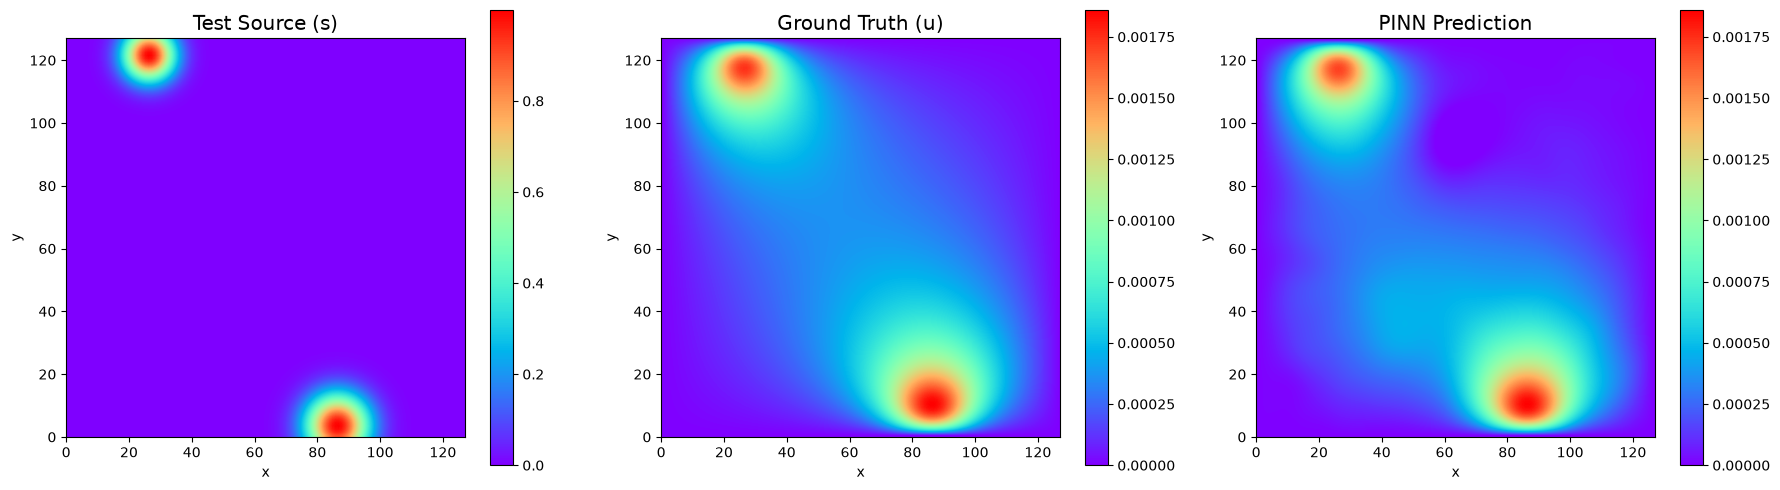

In [15]:
s_sample, u_sim_sample = test_dataset[12]

s_batch = s_sample[None, ...]  

raw_val = params['params']['raw_lambda'][0]
learned_lambda = 10 ** (jnp.tanh(raw_val) * 3 - 2)

rng_plot = jax.random.PRNGKey(1)

plot_spatial_idx = jax.random.choice(rng_plot, jnp.arange(nx * ny), shape=(spatial_batch_size,), replace=False)

w_plot_batch = update_kaczmarz_batch(
    params, 
    x[plot_spatial_idx], 
    y[plot_spatial_idx], 
    s_batch[:, plot_spatial_idx, :], 
    x_bc, y_bc, u_bc, 
    total_features, chunk_size, spatial_chunk_size, kaczmarz_alpha, learned_lambda, kaczmarz_sweeps
)

w_plot = w_plot_batch[0]

u_pred = predict_u_chunked_single(params, x, y, w_plot, total_features, chunk_size)

s_plot = s_sample.reshape(nx, ny).T
u_sim_plot = u_sim_sample.reshape(nx, ny).T 
u_pred_plot = u_pred.reshape(nx, ny).T

u_vmin = u_sim_plot.min()
u_vmax = u_sim_plot.max()

ext = [0, nx - 1, 0, ny - 1]
fig = plt.figure(figsize=(18, 5))

ax1 = fig.add_subplot(1, 3, 1)
mesh1 = ax1.imshow(s_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh1, ax=ax1)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title('Test Source (s)', fontsize='x-large')

ax2 = fig.add_subplot(1, 3, 2)
mesh2 = ax2.imshow(u_sim_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1., vmin=u_vmin, vmax=u_vmax)
fig.colorbar(mesh2, ax=ax2)
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Ground Truth (u)', fontsize='x-large')

ax3 = fig.add_subplot(1, 3, 3)
mesh3 = ax3.imshow(u_pred_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1., vmin=u_vmin, vmax=u_vmax)
fig.colorbar(mesh3, ax=ax3)
ax3.set_xlabel('x')
ax3.set_ylabel('y')
ax3.set_title('PINN Prediction', fontsize='x-large')

plt.tight_layout()
plt.show()